In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix


In [ ]:
# ---- LOAD DATA ----
data = pd.read_csv("/content/creditcard.csv")
print("✅ Data Loaded Successfully\n")
print(data.head())

print("\n📊 Dataset Summary:")
print(data.describe())


✅ Data Loaded Successfully

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

In [ ]:
# ---- BASIC ANALYSIS ----
fraud = data[data['Class'] == 1]
valid = data[data['Class'] == 0]
outlierFraction = len(fraud) / float(len(valid))
print("\n⚠️ Fraud Fraction:", outlierFraction)
print('Fraud Cases:', len(fraud))
print('Valid Transactions:', len(valid))


⚠️ Fraud Fraction: 0.0017304750013189597
Fraud Cases: 492
Valid Transactions: 284315


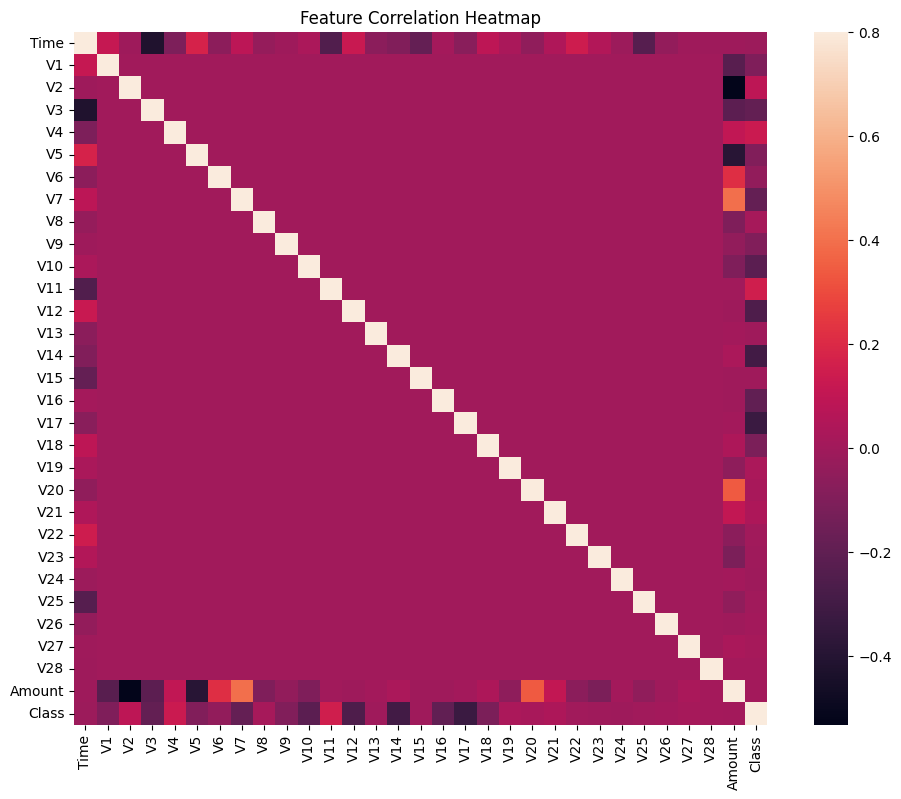

In [ ]:
# ---- CORRELATION HEATMAP ----
corrmat = data.corr()
fig = plt.figure(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# ---- DATA CLEANING ----
print("\n🧹 Checking and cleaning data...")

# Replace infinite values with NaN
data = data.replace([np.inf, -np.inf], np.nan)

# Show total missing values
print("Missing values before cleaning:", data.isnull().sum().sum())

# Drop rows with NaN
data = data.dropna()

# Show remaining missing values
print("Missing values after cleaning:", data.isnull().sum().sum())


🧹 Checking and cleaning data...
Missing values before cleaning: 0
Missing values after cleaning: 0


In [ ]:
# ---- FEATURE SELECTION ----
X = data.drop(['Class'], axis=1)
Y = data["Class"]
print("\n✅ Data ready for model")
print("Feature Shape:", X.shape)
print("Label Shape:", Y.shape)


✅ Data ready for model
Feature Shape: (284807, 30)
Label Shape: (284807,)


In [ ]:
# ---- TRAIN-TEST SPLIT ----
xTrain, xTest, yTrain, yTest = train_test_split(
    X.values, Y.values, test_size=0.2, random_state=42
)

In [ ]:
# ---- MODEL TRAINING ----
rfc = RandomForestClassifier(random_state=42)
rfc.fit(xTrain, yTrain)

RandomForestClassifier(random_state=42)

In [ ]:
# ---- PREDICTION ----
yPred = rfc.predict(xTest)


In [ ]:
# ---- MODEL EVALUATION ----
accuracy = accuracy_score(yTest, yPred)
precision = precision_score(yTest, yPred)
recall = recall_score(yTest, yPred)
f1 = f1_score(yTest, yPred)
mcc = matthews_corrcoef(yTest, yPred)

print("\n📈 Model Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")


📈 Model Evaluation Metrics:
Accuracy: 0.9996
Precision: 0.9740
Recall: 0.7653
F1-Score: 0.8571
Matthews Correlation Coefficient: 0.8632


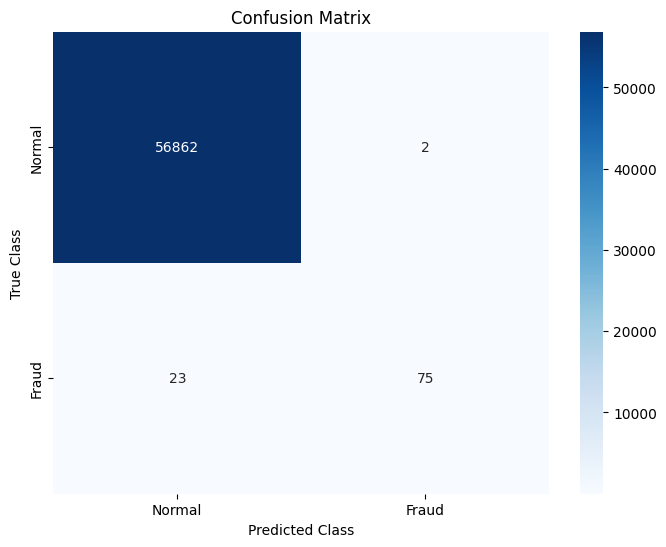

In [ ]:
# ---- CONFUSION MATRIX ----
conf_matrix = confusion_matrix(yTest, yPred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()


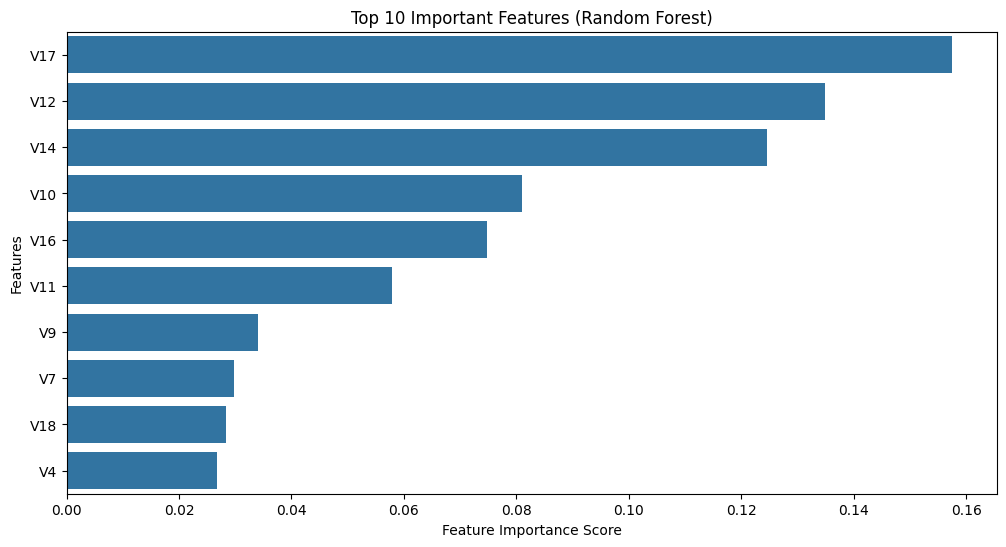

In [ ]:
# ---- FEATURE IMPORTANCE ----
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

importances = rfc.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(12,6))
sns.barplot(x=importances[indices][:10], y=features[indices][:10])
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.show()


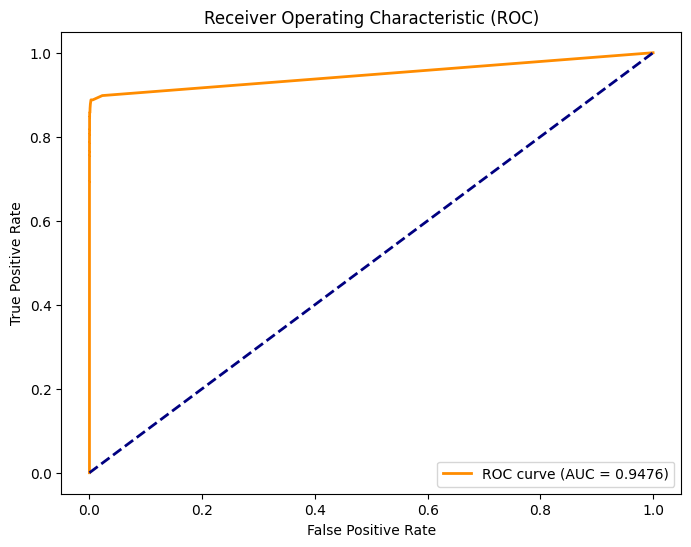

ROC AUC Score: 0.9476


In [ ]:
# ---- ROC CURVE & AUC ----
from sklearn.metrics import roc_curve, roc_auc_score

yPredProb = rfc.predict_proba(xTest)[:, 1]
roc_auc = roc_auc_score(yTest, yPredProb)

fpr, tpr, thresholds = roc_curve(yTest, yPredProb)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")


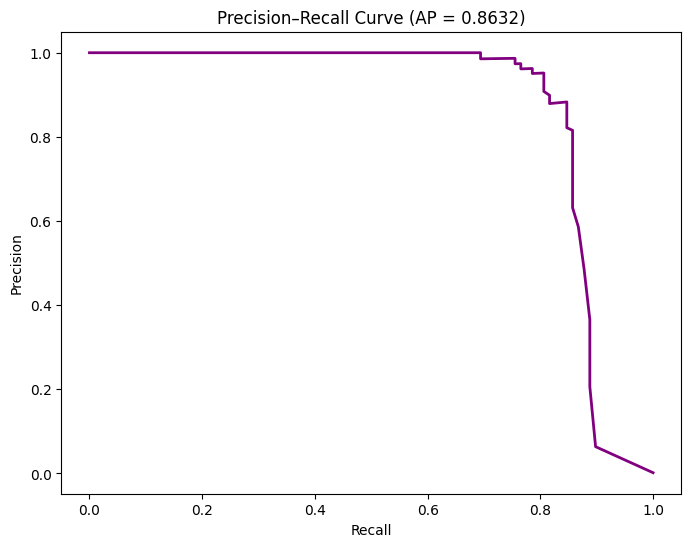

In [ ]:
# ---- PRECISION–RECALL CURVE ----
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(yTest, yPredProb)
avg_precision = average_precision_score(yTest, yPredProb)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve (AP = %0.4f)' % avg_precision)
plt.show()


In [ ]:
# ---- SAVE TRAINED MODEL ----
import joblib

joblib.dump(rfc, "fraud_detection_random_forest.joblib")
print("✅ Model saved as fraud_detection_random_forest.joblib")


✅ Model saved as fraud_detection_random_forest.joblib


In [ ]:
# ---- LOAD MODEL & NEW DATASET ----
import pandas as pd
import joblib

# Load model
rfc = joblib.load("fraud_detection_random_forest.joblib")

# Load external dataset (synthetic or real)
ext_data = pd.read_csv("/content/test_data_3.csv")  # change filename if needed
print("External dataset shape:", ext_data.shape)
display(ext_data.head())


External dataset shape: (20000, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,85540.0,1.123836,-0.098215,0.682728,0.777975,-0.509141,0.067588,-0.315293,0.176479,0.362263,...,0.002824,0.247292,-0.045114,0.281630,0.450607,0.438482,-0.003890,-0.000941,6.99,0
1,56452.0,1.255980,0.214832,0.026715,0.320239,-0.240777,-1.225927,0.385727,-0.379881,-0.139527,...,-0.043199,-0.095416,-0.082060,0.456210,0.544130,0.595690,-0.067867,0.007705,27.00,0
2,77603.0,-0.733736,1.298741,0.889507,0.059689,-0.138997,-0.565776,0.277169,0.506409,-0.528089,...,-0.193201,-0.608393,0.087902,0.013766,-0.215848,0.104727,0.132908,0.031803,9.99,0
3,102814.0,-1.159317,0.664779,2.175679,-0.034821,0.942446,0.192630,0.838885,-0.174795,1.260934,...,-0.423822,-0.864135,-0.025748,0.458715,0.513740,-1.036156,-0.233925,-0.156781,39.40,0
4,47458.0,-0.801353,0.686460,1.360156,-0.348224,0.692191,0.925830,0.635773,0.167023,-0.371374,...,-0.289060,-0.777188,-0.413419,-1.357041,0.459488,0.289890,-0.093152,0.036341,54.99,0


In [ ]:
import pandas as pd

data = pd.read_csv("/content/test_data_3.csv")
print("Shape:", data.shape)
print("\nUnique values in Class column:")
print(data['Class'].value_counts(dropna=False))
print("\nClass column type:", data['Class'].dtype)


Shape: (20000, 31)

Unique values in Class column:
Class
0    19850
1      150
Name: count, dtype: int64

Class column type: int64


In [ ]:
# ---- PREPARE EXTERNAL DATA ----
if 'Class' in ext_data.columns:
    ext_data_features = ext_data.drop(['Class'], axis=1)
else:
    ext_data_features = ext_data.copy()

xExternal = ext_data_features.values


In [ ]:
# ---- PREDICT FRAUDS ----
yExtPred = rfc.predict(xExternal)
yExtProb = rfc.predict_proba(xExternal)[:, 1]

ext_data['Predicted_Class'] = yExtPred
ext_data['Fraud_Probability'] = yExtProb


In [ ]:
# ---- COUNT PREDICTED FRAUD CASES ----
num_frauds = (ext_data['Predicted_Class'] == 1).sum()
num_valid = (ext_data['Predicted_Class'] == 0).sum()

print("Total Transactions:", len(ext_data))
print("Predicted Fraudulent Transactions:", num_frauds)
print("Predicted Normal Transactions:", num_valid)
print(f"Fraud Percentage: {(num_frauds / len(ext_data)) * 100:.2f}%")


Total Transactions: 20000
Predicted Fraudulent Transactions: 147
Predicted Normal Transactions: 19853
Fraud Percentage: 0.73%


In [ ]:
# ---- SHOW TOP SUSPECTED FRAUDS ----
suspected_frauds = ext_data[ext_data['Predicted_Class'] == 1].sort_values(
    by="Fraud_Probability", ascending=False)

print(f"Showing {len(suspected_frauds)} detected fraud transactions:")
display(suspected_frauds.head(10))

# ---- SAVE OUTPUT ----
ext_data.to_csv("fraud_predictions_output.csv", index=False)
print("✅ Results saved as fraud_predictions_output.csv")


Showing 92 detected fraud transactions:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Predicted_Class,Fraud_Probability
5934,95628.0,-17.518909,12.572118,-19.038538,11.190895,-13.554721,-0.411924,-23.189397,-5.301412,-8.630390,...,1.841248,0.334418,-0.720128,-0.232603,-3.021992,-0.478158,1.63,1,1,1.0
12741,41203.0,-8.426814,6.241659,-9.946470,8.199614,-8.213093,-2.522046,-11.643028,5.339500,-7.051016,...,0.020305,0.499809,0.467594,0.483162,1.195671,0.198294,88.23,1,1,1.0
7284,100298.0,-22.341889,15.536133,-22.865228,7.043374,-14.183129,-0.463145,-28.215112,-14.607791,-9.481456,...,1.412928,0.382801,0.447154,-0.632816,-4.380154,-0.467863,1.00,1,1,1.0
6128,40662.0,-4.446847,-0.014793,-5.126307,6.945130,5.269255,-4.297177,-2.591242,0.342671,-3.880663,...,-0.226017,-0.401236,0.856124,0.661272,0.492560,0.971834,1.00,1,1,1.0
22986,7543.0,0.329594,3.712889,-5.775935,6.078266,1.667359,-2.420168,-0.812891,0.133080,-2.214311,...,-0.551572,-0.716522,1.415717,0.555265,0.530507,0.404474,1.00,1,1,1.0
23489,93860.0,-10.632375,7.251936,-17.681072,8.204144,-10.166591,-4.510344,-12.981606,6.783589,-4.659330,...,-1.138122,0.459442,0.386337,0.522438,-1.416604,-0.488307,188.52,1,1,1.0
21767,85867.0,-3.586964,2.609127,-5.568577,3.631947,-4.543590,-0.157899,-4.089128,2.417305,-3.239901,...,0.182032,-0.534598,0.168933,-0.149844,0.685517,-0.299728,310.42,1,1,1.0
21519,102542.0,-1.456876,3.740306,-7.404518,7.440964,-1.549878,-1.661697,-5.757213,1.615011,-2.194881,...,-0.044704,-0.544962,-0.757757,-0.005352,0.318152,-0.323554,2.28,1,1,1.0
37259,93879.0,-13.086519,7.352148,-18.256576,10.648505,-11.731476,-3.659167,-14.873658,8.810473,-5.418204,...,-0.412861,0.519952,-0.743909,-0.167808,-2.498300,-0.711066,30.31,1,1,1.0
37007,88672.0,-3.859881,2.632881,-5.264265,3.446113,-0.675231,-1.904959,-3.291041,-0.985766,-1.168114,...,0.068412,0.778961,-0.863166,-0.006810,-1.065734,1.773326,1.18,1,1,1.0


✅ Results saved as fraud_predictions_output.csv
